# AdaBoost

* ### AdaBoost Explaination

<img src="adaboost.png" width="650"/>

## Loading Data

In [1]:
import numpy as np
from sklearn.datasets import load_wine

In [2]:
############################################ Task 1 ############################################
# Load the wine dataset
# ----------------------------------------- start here -----------------------------------------

wine = load_wine()  # Load the dataset
X = wine.data    # extract all features
y = wine.target     # extract all targets

## Fitting and Testing Model

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [7]:
############################################ Task 1 ############################################
# Split the dataset into 80% train, 20% test
# ----------------------------------------- start here -----------------------------------------

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [9]:
############################################ Task 1 ############################################
# Train a full decision tree classifier, check its training and test error
# ----------------------------------------- start here -----------------------------------------

# Instantiate a decision tree classifier
dt = DecisionTreeClassifier()

# Fit dt to the training set
dt.fit(X_train, y_train)

# Predict on train dataset
y_pred_train=dt.predict(X_train)

# Print training accuracy 
print("Accuracy_train:",accuracy_score(y_train, y_pred_train))

# Predict on test dataset
y_pred_test=dt.predict(X_test)

# Print test accuracy
print("Accuracy_test:",accuracy_score(y_test, y_pred_test))

Accuracy_train: 1.0
Accuracy_test: 0.9444444444444444


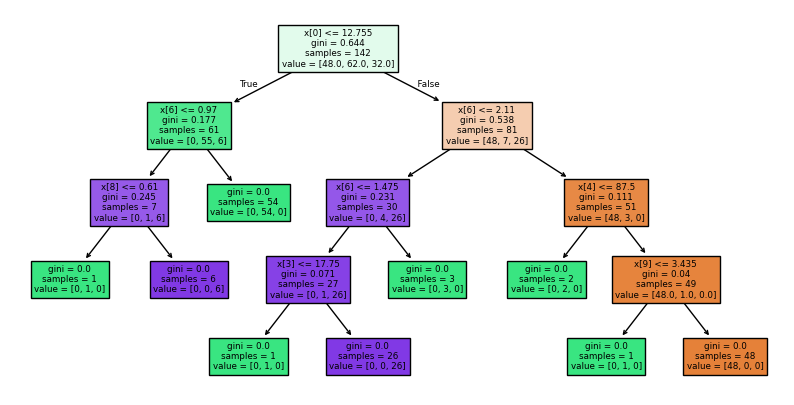

In [11]:
############################################ Task 1 ############################################
# Display the learned classifier
# ----------------------------------------- start here -----------------------------------------

plt.figure(figsize=(10, 5))
plot_tree(dt, filled=True)
plt.show()

In [ ]:
############################################ Task 1 ############################################
# Display the learned classifier
# ----------------------------------------- start here -----------------------------------------

plt.figure(figsize=(10, 5))
plot_tree(dt, filled=True)
plt.show()

In [10]:
############################################ Task 1 ############################################
# Apply the AdaBoost algorithm to this decision tree with T = 10 iterations
# Check again training and test error and output the weights $\alpha_t$
# ----------------------------------------- start here -----------------------------------------

# Set up a AdaBoostClassifier
ada = AdaBoostClassifier(estimator=dt, n_estimators=10)

# Fit ada to the training set
ada.fit(X_train,y_train)

# Predict on train dataset
y_pred_train=ada.predict(X_train)

# Print training accuracy 
print("Accuracy_train:",accuracy_score(y_train, y_pred_train))

# Predict on test dataset
y_pred_test=ada.predict(X_test)

# Print test accuracy
print("Accuracy_test:",accuracy_score(y_test, y_pred_test))

# Print the weights for each estimator in the boosted ensemble
print(ada.estimator_weights_)

Accuracy_train: 1.0
Accuracy_test: 0.8055555555555556
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [12]:
############################################ Task 2 ############################################
# Modify the decision tree learner to have at most n = 2 leaves
# Check its training and test error
# ----------------------------------------- start here -----------------------------------------

# Instantiate dt
dt = DecisionTreeClassifier(max_leaf_nodes=2)

# Fit dt to the training set
dt.fit(X_train, y_train)

# Predict on train dataset
y_pred_train=dt.predict(X_train)

# Print training accuracy 
print("Accuracy_train:", accuracy_score(y_train, y_pred_train))

# Predict on test dataset
y_pred_test=dt.predict(X_test)

# Print test accuracy
print("Accuracy_test:", accuracy_score(y_test, y_pred_test))

Accuracy_train: 0.7253521126760564
Accuracy_test: 0.4722222222222222


In [ ]:
############################################ Task 2 ############################################
# Modify the decision tree learner to have at most n = 2 leaves
# Check its training and test error
# ----------------------------------------- start here -----------------------------------------

# Instantiate dt
dt = DecisionTreeClassifier(max_leaf_nodes=2)

# Fit dt to the training set
dt.fit(X_train, y_train)

# Predict on train dataset
y_pred_train=dt.predict(X_train)

# Print training accuracy 
print("Accuracy_train:", accuracy_score(y_train, y_pred_train))

# Predict on test dataset
y_pred_test=dt.predict(X_test)

# Print test accuracy
print("Accuracy_test:", accuracy_score(y_test, y_pred_test))

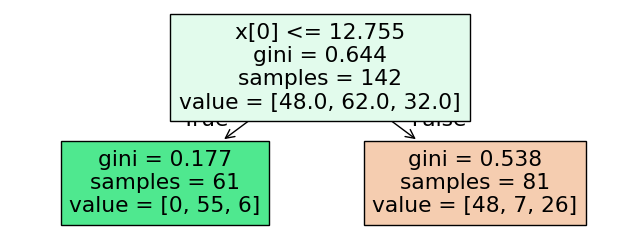

In [14]:
############################################ Task 2 ############################################
# Display the learned classifier
# ----------------------------------------- start here -----------------------------------------

plt.figure(figsize=(8, 3))
plot_tree(dt, filled=True)
plt.show()

In [15]:
############################################ Task 2 ############################################
# Apply the AdaBoost algorithm again with T = 10 iterations
# Check the training and test error and output the weights $\alpha_t$
# ----------------------------------------- start here -----------------------------------------

# Set up a AdaBoostClassifier
ada = AdaBoostClassifier(estimator=dt, n_estimators=10)

# Fit ada to the training set
ada.fit(X_train, y_train)

# Predict on train dataset
y_pred_train=ada.predict(X_train)

# Print training accuracy 
print("Accuracy_train:", accuracy_score(y_train, y_pred_train))

# Predict on test dataset
y_pred_test=ada.predict(X_test)

# Print test accuracy
print("Accuracy_test:", accuracy_score(y_test, y_pred_test))

# Print the weights for each estimator in the boosted ensemble
print(ada.estimator_weights_)

Accuracy_train: 0.9859154929577465
Accuracy_test: 0.9722222222222222
[1.66431452 2.13117267 1.87574433 2.33713232 1.52580604 1.88010369
 2.14149705 1.55913547 1.93587008 1.62421416]


In [17]:
############################################ Task 2 ############################################
# Vary the number of iterations $T \in \{1,\cdots, 25\}$
# Plot the resulting training and test error versus T
# ----------------------------------------- start here -----------------------------------------

# Create empty list to save the training and test accuracy
accuracy_list_train = []
accuracy_list_test = []

for i in range(1,26):

    # Set up a AdaBoostClassifier
    ada = AdaBoostClassifier(estimator=dt, n_estimators=i)

    # Fit ada to the training set
    ada.fit(X_train,y_train)

    # Predict on train dataset
    y_pred_train=ada.predict(X_train)
    
    # Predict on test dataset
    y_pred_test=ada.predict(X_test)

    # Save the training accuracy in the list
    accuracy_list_train.append(accuracy_score(y_train, y_pred_train))
    
    # Save the test accuracy in the list
    accuracy_list_test.append(accuracy_score(y_test, y_pred_test))

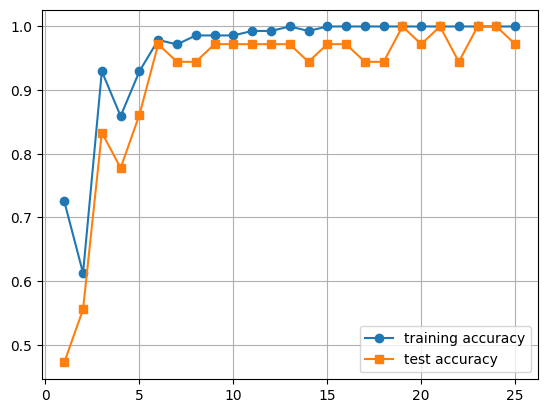

In [19]:
# Plot the resulting training and test accuracy versus the number of iterations
plt.plot(np.arange(1,26), accuracy_list_train, marker='o', label='training accuracy')
plt.plot(np.arange(1,26), accuracy_list_test, marker='s', label='test accuracy')
plt.legend()
plt.grid()